# Cross-method results — comparison table & plots

Walks `checkpoints/{method}/{features}/{level}_{case}/metrics.json`, builds a DataFrame, and produces:
1. Comparison table (CSV at `results/comparison_table.csv`)
2. Per-level accuracy bar chart (top-1 + top-3)
3. Combined learning-curve overlay (per level)
4. Per-parent macro-F1 heatmap for L2

In [1]:
from pathlib import Path
import json
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CKPT_ROOT = Path('checkpoints')
PLOT_ROOT = Path('plots')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Aggregate all `metrics.json` files

In [2]:
rows = []
for metrics_path in CKPT_ROOT.rglob('metrics.json'):
    parts = metrics_path.relative_to(CKPT_ROOT).parts
    if len(parts) < 4:
        continue
    method, features, run_tag = parts[0], parts[1], parts[2]
    level = run_tag.split('_')[0]
    case = '_'.join(run_tag.split('_')[1:]) or 'all'
    with open(metrics_path) as f:
        payload = json.load(f)
    m = payload.get('metrics', {})
    tail = payload.get('tail_report') or {}
    rows.append({
        'method': method,
        'features': features,
        'level': level,
        'case': case,
        'top1': m.get('top1_acc') or m.get('acc'),
        'top3': m.get('top3_acc'),
        'top5': m.get('top5_acc'),
        'macro_f1': m.get('macro_f1'),
        'weighted_f1': m.get('weighted_f1'),
        'n_classes_kept': tail.get('kept_classes'),
        'n_classes_orig': tail.get('orig_classes'),
        'coverage_test': tail.get('coverage_test'),
    })

df = pd.DataFrame(rows).sort_values(['level', 'method', 'features']).reset_index(drop=True)
df.to_csv(RESULTS_DIR / 'comparison_table.csv', index=False)
df

,method,features,level,case,top1,top3,top5,macro_f1,weighted_f1,n_classes_kept,n_classes_orig,coverage_test
0,cnn,deep,L1,all,0.868507,0.978323,0.994888,0.798913,0.868033,NaN,NaN,NaN
1,gat,deep,L1,all,0.847853,0.975051,0.995706,0.767686,0.847225,NaN,NaN,NaN
2,rf,deep,L1,all,0.844172,0.979141,0.997342,0.762528,0.840261,NaN,NaN,NaN
3,rf,raw,L1,all,0.625843,0.901452,0.978532,0.457549,0.585195,NaN,NaN,NaN
4,sgcn,deep,L1,all,0.874438,0.977710,0.994683,0.823506,0.875404,NaN,NaN,NaN
5,sgcn,raw,L1,all,0.685545,0.932529,0.979554,0.574377,0.670629,NaN,NaN,NaN
6,cnn,deep,L2,all,0.458078,0.723722,0.815746,0.329416,0.471777,41.0,59.0,0.991820
7,gat,deep,L2,all,0.460736,0.697955,0.793047,0.299081,0.434942,41.0,59.0,0.991820
8,rf,deep,L2,all,0.522290,0.753374,0.846217,0.325515,0.478795,41.0,59.0,0.991820
9,rf,raw,L2,all,0.334083,0.555306,0.675118,0.220813,0.302476,41.0,59.0,0.991822


## 2. Top-1 / Top-3 bar chart per level

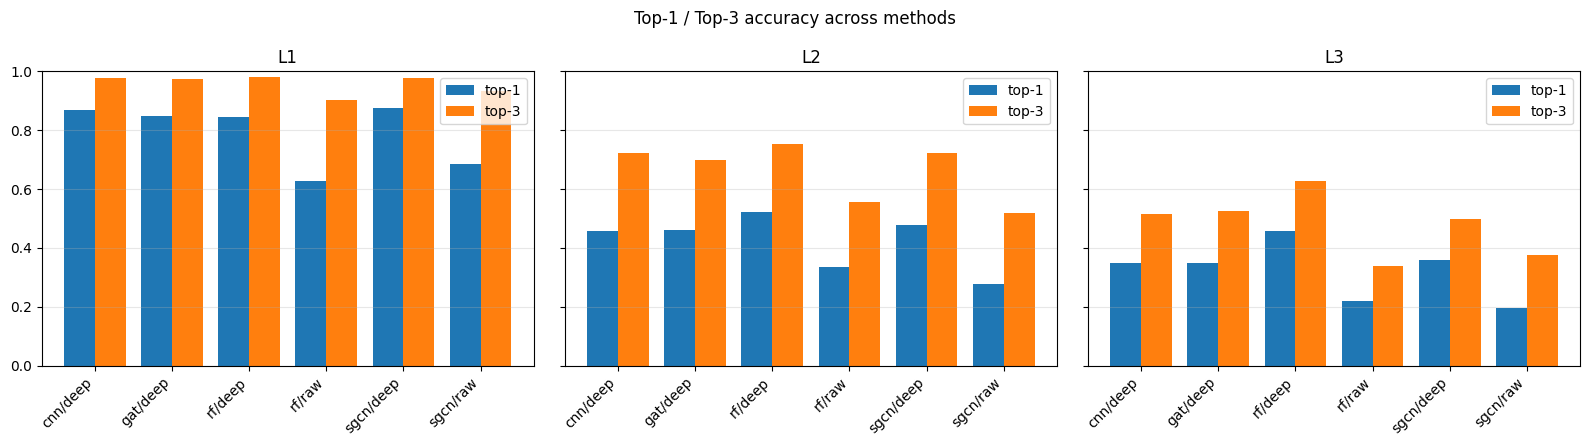

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, level in zip(axes, ['L1', 'L2', 'L3']):
    sub = df[df['level'] == level].copy()
    if sub.empty:
        ax.set_title(f'{level} — no data'); continue
    sub['label'] = sub['method'] + '/' + sub['features']
    x = np.arange(len(sub))
    ax.bar(x - 0.2, sub['top1'].astype(float), 0.4, label='top-1')
    if sub['top3'].notna().any():
        ax.bar(x + 0.2, sub['top3'].astype(float), 0.4, label='top-3')
    ax.set_xticks(x); ax.set_xticklabels(sub['label'], rotation=45, ha='right')
    ax.set_title(level); ax.set_ylim(0, 1); ax.grid(alpha=0.3, axis='y'); ax.legend()
fig.suptitle('Top-1 / Top-3 accuracy across methods')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'topk_per_level.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Learning-curve overlays (validation accuracy per level)

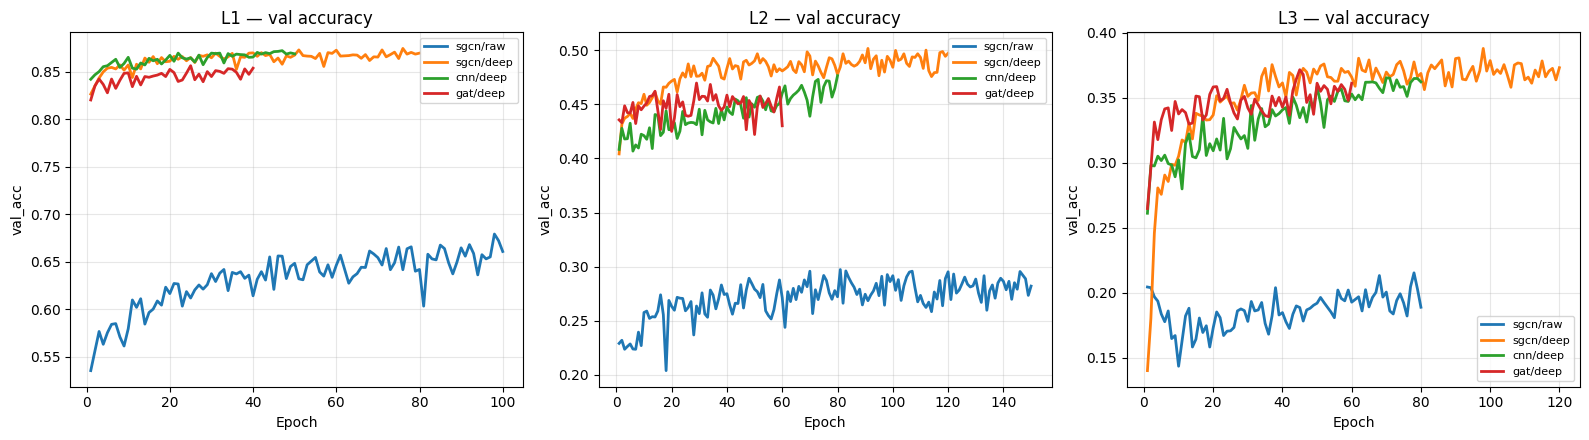

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, level in zip(axes, ['L1', 'L2', 'L3']):
    for metrics_path in CKPT_ROOT.rglob('metrics.json'):
        parts = metrics_path.relative_to(CKPT_ROOT).parts
        if len(parts) < 4:
            continue
        method, features, run_tag = parts[0], parts[1], parts[2]
        if not run_tag.startswith(level + '_'):
            continue
        with open(metrics_path) as f:
            payload = json.load(f)
        h = payload.get('history') or {}
        if not h or not h.get('val_acc'):
            continue
        ax.plot(h['epoch'], h['val_acc'], label=f'{method}/{features}', linewidth=2)
    ax.set_title(f'{level} — val accuracy')
    ax.set_xlabel('Epoch'); ax.set_ylabel('val_acc')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'val_acc_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Best-model summary (per level)

In [5]:
best = (
    df.dropna(subset=['top1'])
      .sort_values('top1', ascending=False)
      .groupby('level').head(1)
      .reset_index(drop=True)
)
print('Best top-1 model per level:')
best

Best top-1 model per level:


,method,features,level,case,top1,top3,top5,macro_f1,weighted_f1,n_classes_kept,n_classes_orig,coverage_test
0,sgcn,deep,L1,all,0.874438,0.977710,0.994683,0.823506,0.875404,NaN,NaN,NaN
1,rf,deep,L2,all,0.522290,0.753374,0.846217,0.325515,0.478795,41.0,59.0,0.991820
2,rf,deep,L3,all,0.457260,0.625971,0.703476,0.269936,0.424784,93.0,209.0,0.953374
